# Decision Engine for Customer Retention

This notebook transforms churn model outputs into clear business actions.

Instead of only predicting which customers may churn, the goal here is to help a business decide:
- who needs urgent retention attention
- who is valuable enough for upsell opportunities
- who can simply be monitored

This makes the project more practical by connecting machine learning predictions to real business decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_scored_data.csv")

## 1. Define Business Thresholds

To make the model actionable, thresholds are used to separate customers by churn risk and customer value.

- **High churn risk threshold = 0.60**
  - Customers above this level are treated as more likely to leave.
- **High value threshold = 0.70**
  - Customers above this level are treated as strategically important customers.

These thresholds help prioritize limited business resources toward the customers who matter most.

These thresholds were selected based on model score distribution and business prioritization needs. 
In a real-world scenario, they would be optimized using cost-based evaluation or A/B testing.

In [2]:
HIGH_RISK = 0.6
HIGH_VALUE = 0.7

## 2. Create Action Rules

A rule-based decision engine is created to assign a recommended business action to each customer.

The logic is:

- **High risk + high value**: urgent retention action
- **High risk only**: retention campaign
- **High value only**: upsell or premium offer
- **Neither**: maintain and monitor

This step turns model scores into understandable recommendations for decision-makers.

In [3]:
def assign_action(row):
    if row["churn_probability"] >= HIGH_RISK and row["value_score"] >= HIGH_VALUE:
        return " High Priority Retention (Offer discount / Call customer)"
    
    elif row["churn_probability"] >= HIGH_RISK:
        return " Retention Campaign (Email / Promotion)"
    
    elif row["value_score"] >= HIGH_VALUE:
        return " Upsell / Premium Offer"
    
    else:
        return " Maintain / Monitor"

## 3. Assign Recommended Actions

The action rules are now applied to each customer record to generate a new column called `recommended_action`.

This gives each customer a suggested intervention based on their churn probability and business value.

In [4]:
df["recommended_action"] = df.apply(assign_action, axis=1)

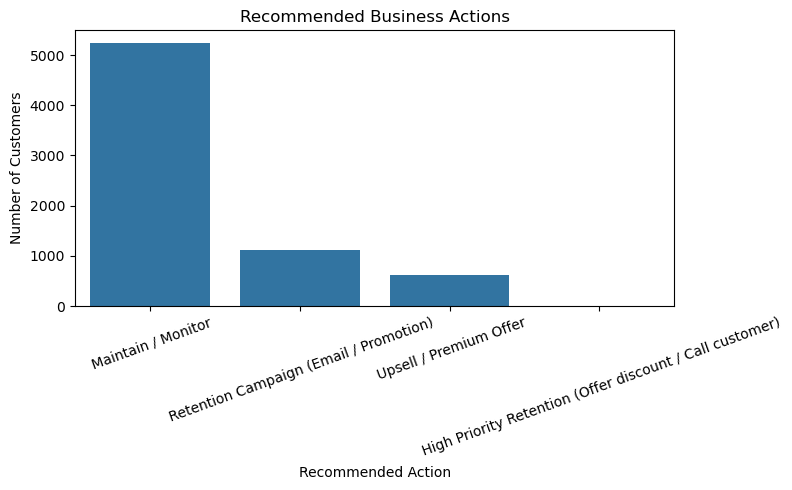

In [5]:
action_counts = df["recommended_action"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=action_counts.index, y=action_counts.values)
plt.title("Recommended Business Actions")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Visual Insight

This chart shows how many customers fall into each business action group.

It is useful for estimating operational workload, such as:
- how many customers need immediate retention action
- how many can be targeted with campaigns
- how many represent upsell potential

## 4. Create Customer Categories

To make analysis easier, customers are also grouped into strategic segments:

- **At-Risk High Value**
- **At-Risk Low Value**
- **Loyal High Value**
- **Stable Customer**

These categories make it easier for managers to understand the customer base and prioritize responses.

In [6]:
def categorize_customer(row):
    if row["churn_probability"] >= HIGH_RISK and row["value_score"] >= HIGH_VALUE:
        return "At-Risk High Value"
    
    elif row["churn_probability"] >= HIGH_RISK:
        return "At-Risk Low Value"
    
    elif row["value_score"] >= HIGH_VALUE:
        return "Loyal High Value"
    
    else:
        return "Stable Customer"

df["customer_category"] = df.apply(categorize_customer, axis=1)

## 5. Review Customer Segment Distribution

Next, we examine how customers are distributed across the defined decision categories.

This helps answer an important business question:

**Are most customers stable, or is there a large group that needs intervention?**

In [7]:
df["customer_category"].value_counts()

customer_category
Stable Customer       5232
At-Risk Low Value     1124
Loyal High Value       628
At-Risk High Value       6
Name: count, dtype: int64

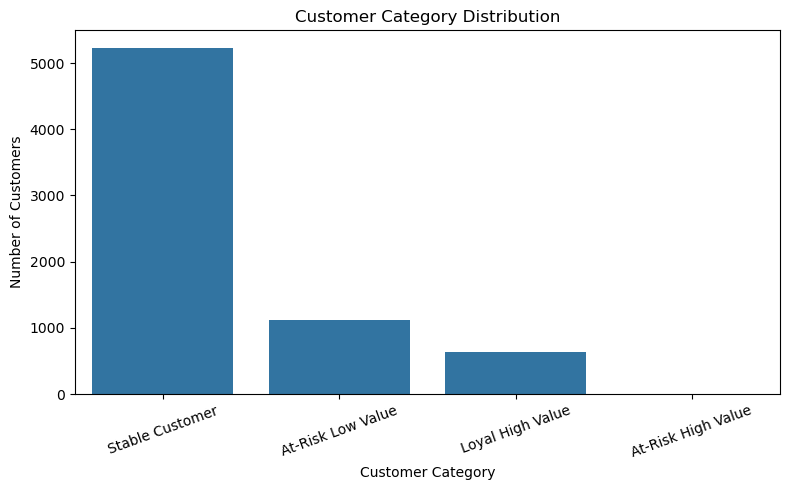

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = df["customer_category"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title("Customer Category Distribution")
plt.xlabel("Customer Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Visual Insight

This chart gives a quick view of how the decision engine segments the customer base.

It helps show whether the business challenge is mostly:
- retention-focused,
- growth-focused,
- or centered around maintaining a stable customer base.

## 6. Estimate Revenue at Risk

A key business KPI is the total revenue associated with high-risk customers.

By summing the total charges of customers above the churn-risk threshold, we can estimate how much revenue may be exposed if these customers leave.

In [9]:
at_risk = df[df["churn_probability"] >= HIGH_RISK]

revenue_at_risk = at_risk["Total Charges"].sum()

print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 867071.1


### Insight

Revenue at risk is one of the most important outputs of this notebook because it translates churn into financial impact.

This metric helps the business:
- understand the potential cost of customer loss
- justify retention spending
- prioritize intervention strategies based on financial exposure rather than only customer count

## 7. Identify Top-Priority Customers

The final step is to rank customers by:

1. **highest churn probability**
2. **highest value score**

This creates a priority list of customers who should be reviewed first by the business team.

In practice, this kind of ranked output can support CRM workflows, retention teams, and account managers.

In [10]:
df.sort_values(
    by=["churn_probability", "value_score"],
    ascending=[False, False]
).head(10)

,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,...,high_risk,cluster,segment,churn_probability,churn_prediction,predicted_value,value_score,value_segment,recommended_action,customer_category
587,0,1,0,1,Yes,Fiber optic,Yes,No,Yes,No,...,1,0,High Value Loyal,0.962393,1,119.148026,0.053794,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
581,1,1,0,1,Yes,Fiber optic,No,No,Yes,No,...,1,0,High Value Loyal,0.961354,1,97.013990,0.051329,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
880,1,1,0,1,Yes,Fiber optic,No,No,No,No,...,1,0,High Value Loyal,0.950908,1,22.421225,0.043020,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
984,0,1,0,1,No,Fiber optic,Yes,No,No,No,...,1,0,High Value Loyal,0.948595,1,119.796900,0.053866,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
1693,0,0,0,1,Yes,Fiber optic,No,No,Yes,No,...,1,0,High Value Loyal,0.948172,1,122.705734,0.054190,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
447,0,0,0,1,Yes,Fiber optic,No,No,Yes,No,...,1,0,High Value Loyal,0.944380,1,286.141720,0.072394,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
1597,1,1,0,1,Yes,Fiber optic,No,Yes,No,No,...,1,0,High Value Loyal,0.940822,1,49.884968,0.046079,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
688,0,1,0,1,No,Fiber optic,No,No,No,No,...,1,0,High Value Loyal,0.938699,1,65.288750,0.047795,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
3488,0,0,0,1,No,Fiber optic,No,No,No,Yes,...,1,0,High Value Loyal,0.934674,1,124.149180,0.054351,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value
545,0,0,0,1,No,Fiber optic,Yes,No,No,No,...,1,0,High Value Loyal,0.934000,1,124.149180,0.054351,Low Value,Retention Campaign (Email / Promotion),At-Risk Low Value


### Insight

This ranked table is highly useful in a real business setting because it shows exactly where action should start.

Rather than treating all customers equally, the company can focus first on customers who are both:
- most likely to churn
- most valuable to the business

## 8. Export Business-Ready Output

The final dataset is exported so it can be used in dashboards, CRM systems, reporting tools, or operational workflows.

This makes the analysis easier to share and closer to a real-world deployment scenario.

In [11]:
df.to_csv("business_ready_data.csv", index=False)

## Final Conclusion

This notebook extends the churn prediction project from analytics into decision support.

By combining churn probability with customer value, the model helps the business:
- identify the most urgent retention cases
- target lower-value at-risk customers with scalable campaigns
- recognize loyal high-value customers for growth opportunities
- estimate the financial impact of churn through revenue at risk

This is an important step because it shows how predictive analytics can directly support business strategy and customer relationship management.|

## Business Recommendations

- Focus retention efforts on high-value at-risk customers first
- Use automated campaigns for low-value at-risk customers
- Develop loyalty programs for high-value stable customers
- Monitor model thresholds to ensure accurate prioritization